In [18]:
import pandas as pd
import numpy as np
from datetime import datetime

In [19]:
dataset = pd.read_csv(r'../data/NepalLatestAQI.csv')
dataset.head()

,date,station,latitude,longitude,aqi,pm2_5,pm10,no2,so2,o3,temperature_C,relative_humidity_%,notes
0,2024-01-01,Kathmandu,27.7172,85.3240,162,75.9,161.5,18.5,8.0,16.2,20.9,65.2,NaN
1,2024-01-01,Lalitpur,27.6648,85.3188,157,66.9,105.9,18.2,4.2,34.1,28.8,76.2,NaN
2,2024-01-01,Bhaktapur,27.6714,85.4270,166,84.8,182.9,16.4,7.1,26.7,20.3,60.9,NaN
3,2024-01-01,Pokhara,28.2096,83.9856,79,25.5,47.8,2.0,1.0,31.7,23.0,47.9,NaN
4,2024-01-01,Biratnagar,26.4525,87.2718,146,53.8,86.3,17.2,1.9,34.5,23.9,54.1,NaN


In [20]:
dataset.isnull().sum()

date                      0
station                   0
latitude                  0
longitude                 0
aqi                       0
pm2_5                     0
pm10                      0
no2                       0
so2                       0
o3                        0
temperature_C             0
relative_humidity_%       0
notes                  9761
dtype: int64

In [21]:
dataset = dataset.drop(columns='notes')

In [22]:
dataset = dataset.rename(columns=lambda c: c.strip())

In [23]:
dataset = dataset.sort_values('date').drop_duplicates(subset=['station', 'date'], keep='last')

In [24]:
dataset['date'] = pd.to_datetime(dataset['date'])
dataset['month'] = dataset['date'].dt.month
dataset['day'] = dataset['date'].dt.day
dataset['dayofweek'] = dataset['date'].dt.dayofweek
dataset['is_weekend'] = dataset['dayofweek'].isin([5,6]).astype(int)

❗ Why do we encode cyclical features?

Months and weekdays are cyclical:

After December (12) comes January (1)

After Sunday (6) comes Monday (0)

If you use raw numbers:

The model thinks January (1) is far from December (12)
But they are next to each other.

In [25]:
dataset['month_sin'] = np.sin(2 * np.pi * dataset['month']/12)
dataset['month_cos'] = np.cos(2 * np.pi * dataset['month']/12)
dataset['dow_sin'] = np.sin(2 * np.pi * dataset['dayofweek']/7)
dataset['dow_cos'] = np.cos(2 * np.pi * dataset['dayofweek']/7)


In [26]:
dataset.columns

Index(['date', 'station', 'latitude', 'longitude', 'aqi', 'pm2_5', 'pm10',
       'no2', 'so2', 'o3', 'temperature_C', 'relative_humidity_%', 'month',
       'day', 'dayofweek', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin',
       'dow_cos'],
      dtype='object')

In [27]:
cols = ['aqi', 'pm2_5', 'pm10', 'no2', 'so2', 'o3', 'temperature_C', 'relative_humidity_%']

In [28]:
lags = [1, 3, 7]
rolls = [3, 7]

In [29]:
dataset = dataset.sort_values(['station', 'date']).reset_index(drop=True)

# Lags & rolling use only past values (shifted), so no leakage occurs

In [30]:
# create lag feature
for c in cols:
    for lag in lags:
        new_col = f"{c}_lag{lag}"
        dataset[new_col] = dataset.groupby('station')[c].shift(lag)

In [31]:
# crete rolling-mean features
for c in cols:
    for w in rolls:
        new_col = f"{c}_roll{w}"
        dataset[new_col] = (dataset.groupby('station')[c].transform(lambda s: s.rolling(window=w, min_periods=1).mean().shift(1)))

In [32]:
new_features = [c for c in dataset.columns if any(x in c for x in ['_lag', '_roll'])]
print(f"Added {len(new_features)} features: {new_features[:20]}{'' if len(new_features)<=20 else ' ...'}")
print("\nMissing values count for new features:")
print(dataset[new_features].isnull().sum())

Added 40 features: ['aqi_lag1', 'aqi_lag3', 'aqi_lag7', 'pm2_5_lag1', 'pm2_5_lag3', 'pm2_5_lag7', 'pm10_lag1', 'pm10_lag3', 'pm10_lag7', 'no2_lag1', 'no2_lag3', 'no2_lag7', 'so2_lag1', 'so2_lag3', 'so2_lag7', 'o3_lag1', 'o3_lag3', 'o3_lag7', 'temperature_C_lag1', 'temperature_C_lag3'] ...

Missing values count for new features:
aqi_lag1                      15
aqi_lag3                      45
aqi_lag7                     105
pm2_5_lag1                    15
pm2_5_lag3                    45
pm2_5_lag7                   105
pm10_lag1                     15
pm10_lag3                     45
pm10_lag7                    105
no2_lag1                      15
no2_lag3                      45
no2_lag7                     105
so2_lag1                      15
so2_lag3                      45
so2_lag7                     105
o3_lag1                       15
o3_lag3                       45
o3_lag7                      105
temperature_C_lag1            15
temperature_C_lag3            45
temperatur

In [33]:
initial_len = len(dataset)
dataset = dataset[~dataset[new_features].isnull().any(axis=1)].reset_index(drop=True)
dropped = initial_len - len(dataset)
print(f"Dropped {dropped} rows ({dropped/initial_len*100:.2f}%) because lag/roll features were not available.")

Dropped 105 rows (1.07%) because lag/roll features were not available.


In [34]:
dataset['station'].nunique()

15

In [35]:
dataset = pd.get_dummies(dataset, columns=['station'], prefix='st', drop_first=False)

In [36]:
dataset.shape

(9735, 74)

In [37]:
train_end = '2025-05-30'
valid_end = '2025-08-30'

In [38]:
train_data = dataset[ dataset['date'] <= train_end ]
valid_data = dataset[ (dataset['date'] > train_end) & (dataset['date'] <= valid_end) ]
test_data = dataset[ dataset['date'] > valid_end ]

In [39]:
print("Train shape :", train_data.shape)
print("Valid shape :", valid_data.shape)
print("Test shape  :", test_data.shape)

Train shape : (7635, 74)
Valid shape : (1380, 74)
Test shape  : (720, 74)


In [40]:
target = 'aqi'
features = [c for c in dataset.columns if c not in ['date', 'aqi']]

In [41]:
x_train = train_data[features]
y_train = train_data[target]

x_valid = valid_data[features]
y_valid = valid_data[target]

x_test = test_data[features]
y_test = test_data[target]

In [42]:
import xgboost as xgb
from xgboost import XGBRegressor

In [43]:
model = XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist",
        verbosity=0,
    )

model.fit(
        x_train, y_train,
        eval_set=[(x_valid, y_valid)],
        verbose=False
    )

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [44]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [45]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100
    return {'mae': mae, 'rsme': rmse, 'mape': mape}

In [46]:
pred_valid = model.predict(x_valid)
pred_test = model.predict(x_test)

In [47]:
metrics_valid = compute_metrics(y_valid, pred_valid)
metrics_test  = compute_metrics(y_test, pred_test)

print("Validation:", metrics_valid)
print("Test      :", metrics_test)

Validation: {'mae': 5.9294047355651855, 'rsme': 31.412899017333984, 'mape': np.float64(10.189712720771064)}
Test      : {'mae': 3.0636353492736816, 'rsme': 23.676902770996094, 'mape': np.float64(2.733366240318653)}


In [48]:
model.score(x_test, y_test)*100

57.524657249450684

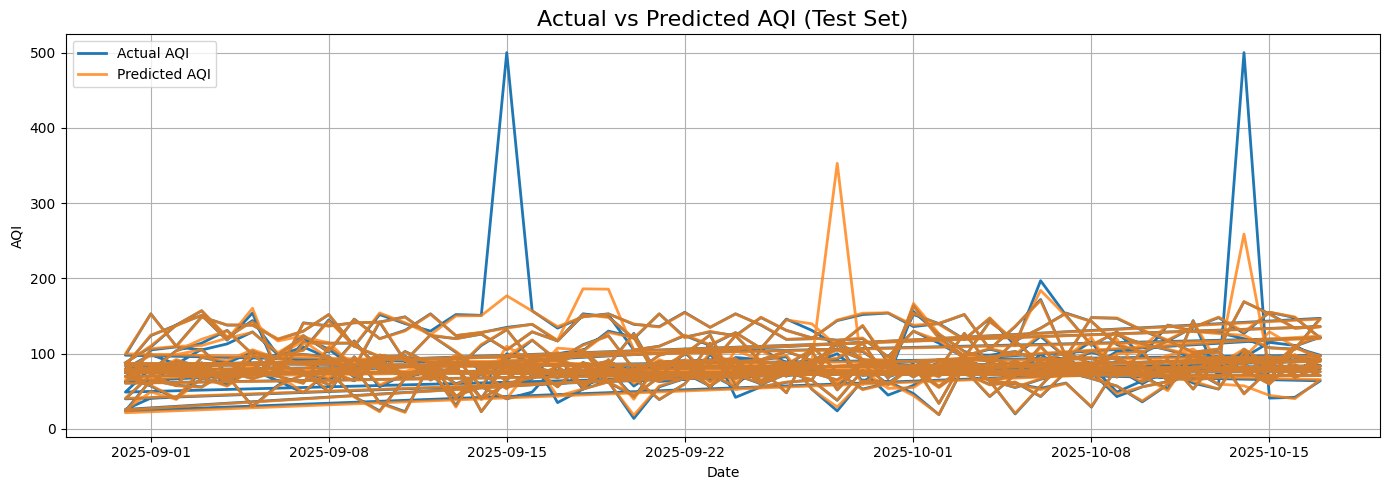

In [49]:
import matplotlib.pyplot as plt

df_plot = test_data.copy().reset_index(drop=True)
df_plot['predicted'] = model.predict(x_test)

plt.figure(figsize=(14,5))
plt.plot(df_plot['date'], df_plot['aqi'], label='Actual AQI', linewidth=2)
plt.plot(df_plot['date'], df_plot['predicted'], label='Predicted AQI', linewidth=2, alpha=0.8)

plt.title("Actual vs Predicted AQI (Test Set)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
